<u><h1>CPSC 440 Project: Road Traffic Accident Dataset Analysis</h1></u>

Reproducing: "Evaluating Road Crash Severity Prediction with Balanced Ensemble Models"
By Alexei Roudnitski (2024) — Published in Findings
DOI: https://doi.org/10.32866/001c.116820

Data source: https://opendata.transport.nsw.gov.au/dataset/nsw-crash-data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    VotingClassifier,
)
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

C:\Users\Nathan\AppData\Local\Temp\ipykernel_29920\1868792246.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# load data
DATA_PATH = "data/nsw_road_crash_data_2018-2022_crash.csv"

df = pd.read_csv(DATA_PATH, encoding="latin1")

In [3]:
# select columns
TARGET = "Degree of crash - detailed"

FEATURES = [
    "Day of week of crash",
    "Distance",
    "Identifying feature type",
    "Type of location",
    "Urbanisation",
    "Alignment",
    "Street lighting",
    "Road surface",
    "Surface condition",
    "Weather",
    "Natural lighting",
    "Signals operation",
    "Other traffic control",
    "Speed limit",
    "Road classification (admin)",
    "First impact type",
    "Key TU type",
    "Other TU type",
    "No. of traffic units involved",
]

df = df[[TARGET] + FEATURES].copy()
print(f"Dataset shape: {df.shape}")
print(f"\nTarget distribution:\n{df[TARGET].value_counts()}")

Dataset shape: (95873, 20)

Target distribution:
Degree of crash - detailed
Non-casualty (towaway)    30771
Moderate Injury           26740
Serious Injury            19700
Minor/Other Injury        17220
Fatal                      1442
Name: count, dtype: int64


In [4]:
# remove rows with unknown values
def remove_unknown_strings_only(df):
    """
    Removes rows where any of the 20 columns contain the word 'unknown',
    but preserves rows that contain actual NaN/Null values.
    """
    # The 20 variables identified in the paper
    features = FEATURES
    
    # Create a mask for 'unknown'
    # We cast to string to use .str.contains, but we must handle NaNs 
    # so they don't get caught in the 'unknown' filter.
    contains_unknown = df[features].apply(
        lambda col: col.astype(str).str.contains('unknown', case=False, na=False)
    ).any(axis=1)
    
    # Filter the dataframe
    df_no_unknowns = df[~contains_unknown].copy()
    
    # Validation
    unknown_count = contains_unknown.sum()
    null_count = df_no_unknowns[features].isnull().any(axis=1).sum()
    
    print(f"Rows removed due to 'unknown' string: {unknown_count}")
    print(f"Rows remaining that still contain NaNs: {null_count}")
    print(f"New dataset shape: {df_no_unknowns.shape}")
    
    return df_no_unknowns

df = remove_unknown_strings_only(df)
print(f"\nTarget distribution:\n{df[TARGET].value_counts()}")

Rows removed due to 'unknown' string: 39076
Rows remaining that still contain NaNs: 20228
New dataset shape: (56797, 20)

Target distribution:
Degree of crash - detailed
Moderate Injury           20224
Serious Injury            17979
Non-casualty (towaway)     9657
Minor/Other Injury         7528
Fatal                      1409
Name: count, dtype: int64


In [5]:
# encode categorical variables
label_encoders = {}
for col in df.columns:
    if df[col].dtype == "object":
        le = LabelEncoder()
        df[col] = df[col].fillna("Missing")
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

X = df[FEATURES]
y = df[TARGET]


In [6]:

# test/train split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=440, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 39757, Test size: 17040


In [7]:
# apply SMOTE on train data
smote = SMOTE(random_state=440)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print(f"Balanced train size: {X_train_bal.shape[0]}")
print(f"Balanced class distribution:\n{pd.Series(y_train_bal).value_counts()}")

Balanced train size: 70780
Balanced class distribution:
Degree of crash - detailed
2    14156
3    14156
4    14156
1    14156
0    14156
Name: count, dtype: int64


In [8]:
# models for ensemble model using paper's hyperparams
rf = RandomForestClassifier(
    max_depth=10,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=100,
    random_state=440,
)

xgb = XGBClassifier(
    learning_rate=0.1,
    max_depth=3,
    min_child_weight=1,
    n_estimators=100,
    eval_metric="mlogloss",
    random_state=440,
)

ada = AdaBoostClassifier(
    learning_rate=0.1,
    n_estimators=50,
    random_state=440,
    algorithm="SAMME",
)

lgbm = LGBMClassifier(
    learning_rate=0.1,
    max_depth=3,
    n_estimators=100,
    random_state=440,
    verbose=-1,
)

cat = CatBoostClassifier(
    learning_rate=0.1,
    max_depth=3,
    iterations=100,
    random_seed=440,
    verbose=0,
)

In [9]:
# soft voting ensemble
ensemble = VotingClassifier(
    estimators=[
        ("rf", rf),
        ("xgb", xgb),
        ("ada", ada),
        ("lgbm", lgbm),
        ("cat", cat),
    ],
    voting="soft",
)

print("\nTraining ensemble model")
ensemble.fit(X_train_bal, y_train_bal)
print("Training complete.")


Training ensemble model
Training complete.


In [10]:
# AUC and feature importances per model
models = {
    "Random Forest": rf,
    "XGBoost": xgb,
    "AdaBoost": ada,
    "LightGBM": lgbm,
    "CatBoost": cat,
}

individual_importances = {}
individual_aucs = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    proba = model.predict_proba(X_test)
    auc = roc_auc_score(y_test, proba, multi_class="ovr", average="macro")
    individual_aucs[name] = auc
    individual_importances[name] = model.feature_importances_
    print(f"{name} — individual AUC: {auc:.3f}")

# weight importances by model AUC, then average and normalize
weighted_sum = np.zeros(len(FEATURES))
total_weight = 0
for name in models:
    w = individual_aucs[name]
    weighted_sum += w * individual_importances[name]
    total_weight += w

weighted_importance = weighted_sum / total_weight
weighted_importance = weighted_importance / weighted_importance.sum()

importance_df = (
    pd.DataFrame({"Feature": FEATURES, "Importance": weighted_importance})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 20 Weighted Feature Importances:")
print(importance_df.head(20).to_string(index=False))

Random Forest — individual AUC: 0.672
XGBoost — individual AUC: 0.673
AdaBoost — individual AUC: 0.614
LightGBM — individual AUC: 0.677
CatBoost — individual AUC: 0.664

Top 20 Weighted Feature Importances:
                      Feature  Importance
                  Key TU type    0.133950
            First impact type    0.132567
                Other TU type    0.127179
                  Speed limit    0.079608
                     Distance    0.066932
                 Urbanisation    0.057408
No. of traffic units involved    0.050458
     Identifying feature type    0.049918
              Street lighting    0.044138
             Natural lighting    0.042908
  Road classification (admin)    0.034680
             Type of location    0.034208
         Day of week of crash    0.033716
            Surface condition    0.025188
                      Weather    0.023633
        Other traffic control    0.022149
                    Alignment    0.018759
            Signals operation    0.01


Feature importance plot saved to feature_importance.png


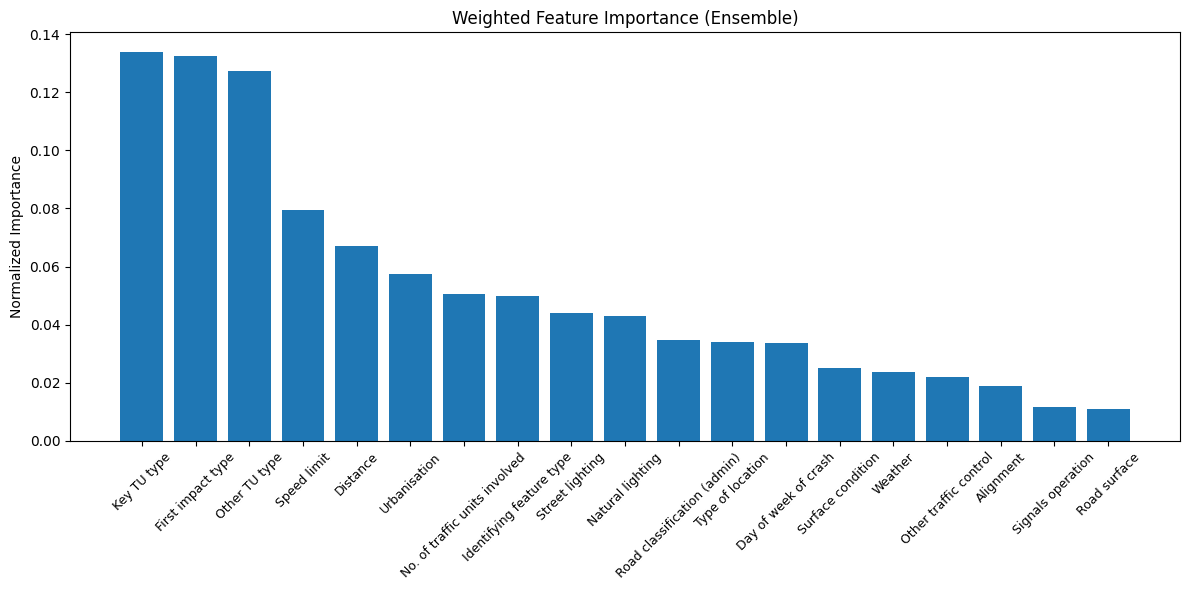

In [11]:
# plot feature importance
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(importance_df["Feature"], importance_df["Importance"])
ax.set_ylabel("Normalized Importance")
ax.set_title("Weighted Feature Importance (Ensemble)")
ax.tick_params(axis="x", rotation=45, labelsize=9)
plt.tight_layout()
plt.savefig("figs/feature_importance.png", dpi=150)
print("\nFeature importance plot saved to feature_importance.png")


Fatal crash instances in test set: 423

Fatal crash profile plot saved to fatal_crash_profile.png


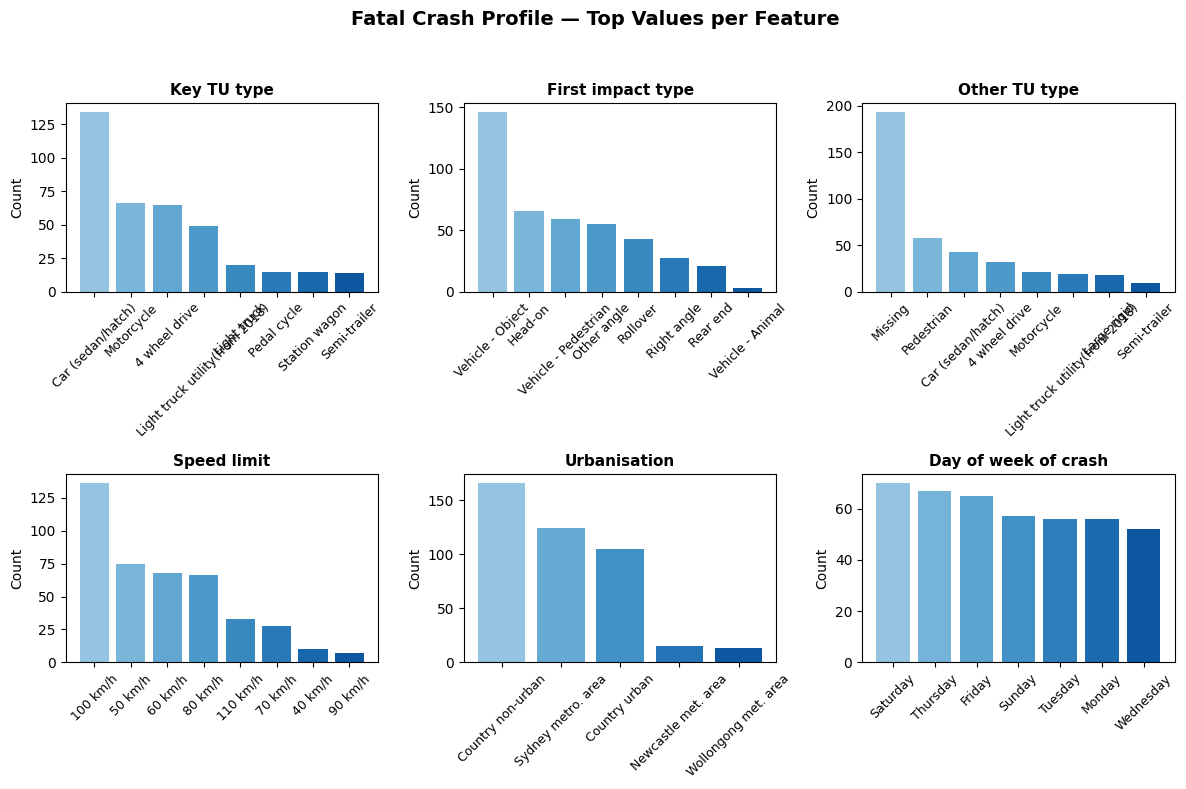

In [12]:
# fatal crash analysis plot
if TARGET in label_encoders:
    le_target = label_encoders[TARGET]
    fatal_label = le_target.transform(["Fatal"])[0]
else:
    fatal_label = "Fatal"
 
fatal_mask = y_test == fatal_label
fatal_cases = X_test[fatal_mask].copy()
 
print(f"\nFatal crash instances in test set: {fatal_cases.shape[0]}")
 
analysis_features = [
    "Key TU type",
    "First impact type",
    "Other TU type",
    "Speed limit",
    "Urbanisation",
    "Day of week of crash",
]
 
for feat in analysis_features:
    if feat in label_encoders:
        le = label_encoders[feat]
        decoded = le.inverse_transform(fatal_cases[feat].astype(int))
        top3 = pd.Series(decoded).value_counts().head(3)
    else:
        top3 = fatal_cases[feat].value_counts().head(3)

# plot 6 graphs at once 
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
 
for i, feat in enumerate(analysis_features):
    ax = axes[i]
    if feat in label_encoders:
        le = label_encoders[feat]
        decoded = pd.Series(le.inverse_transform(fatal_cases[feat].astype(int)))
        counts = decoded.value_counts().head(8)
    else:
        counts = fatal_cases[feat].value_counts().head(8)
 
    labels = [str(l) for l in counts.index]
    colors = plt.cm.Blues(np.linspace(0.4, 0.85, len(counts)))
 
    ax.bar(labels, counts.values, color=colors)
    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", labelsize=9, rotation=45)
 
fig.suptitle("Fatal Crash Profile — Top Values per Feature", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("figs/fatal_crash_profile.png", dpi=150)
print("\nFatal crash profile plot saved to fatal_crash_profile.png")

In [13]:
# evaluate on test set
y_pred = ensemble.predict(X_test)
y_proba = ensemble.predict_proba(X_test)

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")

# precision, recall, F1-score
precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print("\n" + "=" * 50)
print("MODEL PERFORMANCE (expected from paper)")
print("=" * 50)
print(f"ROC-AUC:   {roc_auc:.2f}   (paper: 0.68)")
print(f"Precision: {precision:.2f}   (paper: 0.33)")
print(f"Recall:    {recall:.2f}   (paper: 0.37)")
print(f"F1 Score:  {f1:.2f}   (paper: 0.33)")
print("=" * 50)


MODEL PERFORMANCE (expected from paper)
ROC-AUC:   0.68   (paper: 0.68)
Precision: 0.33   (paper: 0.33)
Recall:    0.37   (paper: 0.37)
F1 Score:  0.33   (paper: 0.33)
